<a href="https://colab.research.google.com/github/joro243/joro243/blob/main/SentimentAnalysisLSTM2109717.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Get Data and import libraries that we need

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 19.4 MB/s eta 0:00:00


In [2]:
# Define where we will download the data
path_data = "/content/sample_data"

Download the data

In [3]:
!wget -P /content/sample_data/ -c "http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

--2025-11-23 17:37:42--  http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
Resolving ai.stanford.edu (ai.stanford.edu)... 171.64.68.10
Connecting to ai.stanford.edu (ai.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84125825 (80M) [application/x-gzip]
Saving to: ‘/content/sample_data/aclImdb_v1.tar.gz’

aclImdb_v1.tar.gz   100%[===================>]  80.23M  8.31MB/s    in 48s     

2025-11-23 17:38:30 (1.67 MB/s) - ‘/content/sample_data/aclImdb_v1.tar.gz’ saved [84125825/84125825]



Decompress the archive

In [4]:
!tar -xf  /content/sample_data/aclImdb_v1.tar.gz -C /content/sample_data/

Check that the folder aclImdb exists

In [5]:
!ls /content/sample_data/

aclImdb		   california_housing_test.csv	 mnist_train_small.csv
aclImdb_v1.tar.gz  california_housing_train.csv  README.md
anscombe.json	   mnist_test.csv


Import all required libraries

In [6]:
import pandas as pd
import numpy as np
import os
from bs4 import BeautifulSoup
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
import nltk
from gensim.models import Word2Vec, Phrases
import matplotlib.pyplot as plt

import tensorflow as tf
from keras.utils import pad_sequences
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

Define function that reads all the files from a given folder

Load data (movie reviews), both for train and test

In [7]:
def read_data(path, files):
  data = []
  for f in files:
    with open(path+f) as file:

      ### BEGIN YOUR CODE HERE
      ## Read a line from the file and append it to the data list variable.
      ## TIP: use function append(): https://www.w3schools.com/python/ref_list_append.asp
      ## and readline(): https://www.w3schools.com/python/ref_file_readline.asp
      data.append(file.readline())



      ### END YOUR CODE HERE
  return data

In [8]:
path_data_train_pos = path_data + '/aclImdb/train/pos/'
path_data_train_neg = path_data + '/aclImdb/train/neg/'
path_data_test_pos = path_data + '/aclImdb/test/pos/'
path_data_test_neg = path_data + '/aclImdb/test/neg/'

# Get the list of files from the four folders
train_pos_files = os.listdir(path_data_train_pos)
train_neg_files = os.listdir(path_data_train_neg)
test_pos_files = os.listdir(path_data_test_pos)
test_neg_files = os.listdir(path_data_test_neg)

In [9]:
### BEGIN YOUR CODE HERE
## Read the review data in these four variables: train_data_pos, train_data_neg,
## test_data_pos and test_data_neg using the function defined above read_data().
## Tip: First argument is the folder containing the files, second argument is
# the list of files
train_data_pos = read_data(path_data_train_pos, train_pos_files)
train_data_neg = read_data(path_data_train_neg, train_neg_files)
test_data_pos = read_data(path_data_test_pos, test_pos_files)
test_data_neg = read_data(path_data_test_neg, test_neg_files)

### END YOUR CODE HERE

# 1a. How many examples do we have in training for positive reviews? How many for negative review?

len(train_data_pos)
len(train_data_neg)


# 1b. How about in the testing set?
len(test_data_pos)
len(test_data_neg)


# Q Is the dataset balanced or not?
#'Yes, the dataset is balanced.'
# 2.Print examples of positive and negative reviews from training and testing dataset
# Tip: the output of the read_data() function is a list.
# https://www.w3schools.com/python/python_lists_access.asp

print(train_data_pos[:3])
print(train_data_pos[:3])

### END YOUR CODE HERE

["Maybe it's because I saw the movie before reading the book, but I really love this movie. I've seen it many many times and will be watching it many times more. It's a compelling story, that's interesting from the beginning to the end. It has everything: action, romance etc.", 'This is one of Jackies best films that is him without opera buddies Sammo Hung and Yuen Biao it has one of the best openings in any action film and it carrys on in that way with Jackie showing some high quality stunts the only critisim is that in the middle it gets a bit slow but it shows up for a frantic last 25 mins in the film and the end credits show what a crazy fool jackie chan is just to keep us film addicts happy', 'Never heard of this movie,saw it on DVD.Great movie,perfect example of a movie that took every cast member to make it work.No overhyped typical Hollywood movie with the same old overhyped actors.No current Quote "A" list actor could have pulled off any performance in this movie.Brought back 

In [10]:
# Let's work on a subset of training and testing dataset to start with.
# I recommend that while you are developing the code to work with a small number of examples, maybe 1000.
# This will speed up how fast you can get the actual results. After the code is working, for the full tests
# please use the entire dataset

### BEGIN YOUR CODE HERE
sample_number = 1000
### END YOUR CODE HERE
train_data_pos = train_data_pos[:sample_number]
train_data_neg = train_data_neg[:sample_number]
test_data_pos = test_data_pos[:sample_number]
test_data_neg = test_data_neg[:sample_number]


Create the data structures that we'll use for training and testing

In [11]:
### BEGIN YOUR CODE HERE
# Assign the length of the train_data_pos to variable length_train_pos
# Tip: to get the length of an array, you can use the function len()

length_train_pos = len(train_data_pos)

# Assign the length of the train_data_neg to variable length_train_neg

length_train_neg = len(train_data_neg)

# Assign the length of the test_data_pos to variable length_test_pos

length_test_pos = len(test_data_pos)

# Assign the length of the test_data_neg to variable length_test_neg

length_test_neg = len(test_data_neg)


### END YOUR CODE HERE

print("Length of the positive training examples is", length_train_pos )
print("Length of the negative training examples is", length_train_neg)
print("Length of the positive testing examples is", length_test_pos )
print("Length of the negative testing examples is", length_test_neg)

Length of the positive training examples is 1000
Length of the negative training examples is 1000
Length of the positive testing examples is 1000
Length of the negative testing examples is 1000


In [12]:
# Create the training DataFrame with examples and labels
# Concatenate positive and negative training examples, then pair each example with a label: 1 for positive, 0 for negative
data_train = pd.DataFrame(zip(train_data_pos+train_data_neg, [1]*length_train_pos+[0]*length_train_neg),  columns=['review', 'label'])
# Create the test DataFrame with examples and labels
# Concatenate positive and negative test examples, then pair each example with a label: 1 for positive, 0 for negative
data_test = pd.DataFrame(zip(test_data_pos+test_data_neg, [1]*length_test_pos+[0]*length_test_pos),  columns=['review', 'label'])
# Combine all reviews into a single list (training + test, positive + negative)
all_reviews = train_data_pos+train_data_neg+test_data_pos+test_data_neg


In [13]:
print("The length of the train reviews is",len(data_train))
print("The length of the test reviews is",len(data_test))
print("The length of all reviews is",len(all_reviews))

The length of the train reviews is 2000
The length of the test reviews is 2000
The length of all reviews is 4000


## The following are functions for preprocessing text

In [14]:
# Download stopwords and wordnet vectors
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

counter = 0
REPLACE_WITH_SPACE = re.compile(r'[^A-Za-z\s]')
stop_words = set(stopwords.words("english"))
# Declare the lemmatizer
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [15]:
# The following functions preprocess text data
def clean_review(raw_review: str) -> str:
    # 1. Remove HTML
    review_text = BeautifulSoup(str(raw_review), "lxml").get_text()
    # 2. Remove non-letters
    letters_only = REPLACE_WITH_SPACE.sub(" ", review_text)
    # 3. Convert to lower case
    lowercase_letters = letters_only.lower()
    return lowercase_letters


def lemmatize(tokens: list) -> list:
    # 1. Lemmatize
    tokens = list(map(lemmatizer.lemmatize, tokens))
    lemmatized_tokens = list(map(lambda x: lemmatizer.lemmatize(x, "v"), tokens))
    # 2. Remove stop words
    meaningful_words = list(filter(lambda x: not x in stop_words, lemmatized_tokens))
    return meaningful_words


def preprocess(review: str, total: int, show_progress: bool = True) -> list:
    if show_progress:
        global counter
        counter += 1
        print('Processing... %6i/%6i'% (counter, total), end='\r')
    # 1. Clean text
    review = clean_review(review)
    # 2. Split into individual words
    tokens = word_tokenize(review)
    # 3. Lemmatize
    lemmas = lemmatize(tokens)
    # 4. Join the words back into one string separated by space,
    # and return the result.
    return lemmas

## Preprocess the text of the reviews by removing the non-word characters, converting everything to lower case, and lemmatizing words


In [16]:
### Begin your code here

# Display the first review text from the training data.
# Purpose: To check how the raw data looks before applying any preprocessing.
# Tip: The training data is stored in a pandas DataFrame (2-dimensional array-like structure).
# Here, we access the 'review' column of the first row.
print(data_train.iloc[0]['review'])

# Display the label associated with the first review in the training data.
# Purpose: To confirm the label for the first review, indicating its classification (1 for positive, 0 for negative).
print(data_train.iloc[0]['label'])

# Display the preprocessed text of the first review.
# Purpose: To see the effect of preprocessing on the raw text.
# Tip: Use the preprocess() function, passing the first review text and specifying "1" as the second argument
# since we're processing a single example.
print(preprocess(data_train.iloc[0]['review'], 1))


### End your code here


Maybe it's because I saw the movie before reading the book, but I really love this movie. I've seen it many many times and will be watching it many times more. It's a compelling story, that's interesting from the beginning to the end. It has everything: action, romance etc.
1
['maybe', 'saw', 'movie', 'read', 'book', 'really', 'love', 'movie', 'see', 'many', 'many', 'time', 'watch', 'many', 'time', 'compel', 'story', 'interest', 'begin', 'end', 'ha', 'everything', 'action', 'romance', 'etc']


Let's preproces the entire set of reviews

In [17]:
# Preprocess each review in all_reviews, applying the preprocess function to each item.
# The preprocess function  takes each review (x) and the total number of reviews (len(all_reviews))
# as inputs, performing some transformation or cleaning on each review based on the dataset size.

all_reviews = [preprocess(x, len(all_reviews)) for x in all_reviews]


In [18]:
# Slice the preprocessed reviews to get only the training set portion (first len(train_data_pos) + len(train_data_neg) items)
X_train_preprocessed = all_reviews[:(len(train_data_pos)+len(train_data_neg))]
X_test_preprocessed = all_reviews[(len(train_data_pos)+len(train_data_neg)):]

In [19]:
len(train_data_pos)

1000

In [20]:
# Let's see how many reviews we have in total for training
# We should get 2000 if you kept the sample_number=1000
# print(X_train_preprocessed.shape)
print(len(X_train_preprocessed))

2000


## Compute Word2Vec vectors on all reviews

In [21]:
# compute bigrams, meaning detect phrases in the texts
# For example: ["new","york"] will be detected as one phrase "new york"
print("Compute phrases begin")
bigrams = Phrases(sentences=all_reviews)
# compute trigrams, meaning we detect three words that usually appear
# together. Notice that because we work with a small subset, we might
# not detect a lot of trigrams
trigrams = Phrases(sentences=bigrams[all_reviews])
print("Compute phrases end")

Compute phrases begin
Compute phrases end


In [22]:
# Test how our phrase looks after calling the bigrams
print(bigrams['space station near the solar system'.split()])

['space', 'station', 'near', 'the', 'solar', 'system']


In [23]:
# Test how our phrase looks after calling the trigrams
# Do you notice any difference compared with the bigrams?
print(trigrams[bigrams['space station near the solar system'.split()]])

['space', 'station', 'near', 'the', 'solar', 'system']


In [24]:
# compute word embedding from the dataset. This might take a while to compute.
### Begin your code here

# set the embedding vector size variable to 256
embedding_vector_size = 256


### End your code here

# Next, we train a custom word2vec model based on our custom dataset.
# Notice that the input sentences are the trigrams
# In this case, we consider grouping like new_york one word.
# The input of the word2vec will be the processed words as trigrams.
# The duration of this process depends on the size of the dataset.
# For the restricted size of all reviews, this would take around 1-2minutes
print("Start learning the word embedding")
trigram_model = Word2Vec(
    sentences = trigrams[bigrams[all_reviews]],
    vector_size = embedding_vector_size,
    min_count=3, window=5, workers=4)
print("Done learning")

Start learning the word embedding
Done learning


Check what is the vocabulary size

In [25]:
print("Vocabulary size:", len(trigram_model.wv))

Vocabulary size: 13535


Let's check the most similar words for "movie" & "galaxy"

In [26]:
trigram_model.wv.most_similar('sun')
# If you are working with the subset of 1000 reviews, the most similar words might not be
# the most relevant ones. You can remove the constraint of working with only 1000 reviews,
# and compare what are the most similar words again, but please be aware that this might
# increase the training time of the word2vec

[('victim', 0.999721109867096),
 ('boyfriend', 0.9996687173843384),
 ('road', 0.9996616244316101),
 ('force', 0.9996547102928162),
 ('land', 0.9996529817581177),
 ('water', 0.9996485710144043),
 ('visit', 0.9996429681777954),
 ('arm', 0.9996347427368164),
 ('hero', 0.999630868434906),
 ('country', 0.9996283054351807)]

In [27]:
trigram_model.wv.most_similar('action')

[('suspense', 0.9995080232620239),
 ('bad_act', 0.9994184970855713),
 ('soundtrack', 0.9994046092033386),
 ('cheesy', 0.9993604421615601),
 ('sound', 0.9993013739585876),
 ('storyline', 0.9992002248764038),
 ('animation', 0.9991897344589233),
 ('although', 0.9990199208259583),
 ('potential', 0.9990140199661255),
 ('predictable', 0.9989567399024963)]

Given a list of words identify which word does not match with the others

In [28]:
trigram_model.wv.doesnt_match(['moon', 'sun', 'planet'])

'sun'

# Transform our reviews from the training set into vectors

In [29]:
# This took for me around 8 minutes

def vectorize_data(data, vocab: dict) -> list:
    print('Vectorize sentences...', end='\r')
    keys = list(vocab.keys())
    filter_unknown = lambda word: vocab.get(word, None) is not None
    encode = lambda review: list(map(keys.index, filter(filter_unknown, review)))
    vectorized = list(map(encode, data))
    print('Vectorize sentences... (done)')
    return vectorized

print('Convert sentences to sentences with ngrams...', end='\r')
X_data = trigrams[bigrams[X_train_preprocessed]]
print('Convert sentences to sentences with ngrams... (done)')
input_length = 150

# Transform all sequences to 150, sequences shorter are padded, while sequences longer are truncated to maximum size
X_pad_train = pad_sequences(
    sequences=vectorize_data(X_data, vocab=trigram_model.wv.key_to_index),
    maxlen=input_length,
    padding='post')
print('Transform sentences to sequences on the train set... (done)')


X_data_test = trigrams[bigrams[X_test_preprocessed]]
X_pad_test = pad_sequences(
    sequences=vectorize_data(X_data_test, vocab=trigram_model.wv.key_to_index),
    maxlen=input_length,
    padding='post')

print('Transform sentences to sequences on the test set... (done)')

Convert sentences to sentences with ngrams... (done)
Vectorize sentences... (done)
Transform sentences to sequences on the train set... (done)
Vectorize sentences... (done)
Transform sentences to sequences on the test set... (done)


In [30]:
# For a given example, each number in the vector represents the position of the word in the vocabulary
X_pad_train[2]

array([2239,    0,  120,  201,   24,    0, 3832,    0,   38,  146, 2935,
          4,   43,  607,  215,    0,  133,   46, 1684, 1394,  577,   46,
         39,  515,   71,    0, 2238,  817, 1051, 8838,  760,  291, 2623,
         26,  622,  255,    1,  346,   11,  673,  672,   16, 4943, 1653,
       1592,   26,  283,  760,   40,  167,  291,  127, 2532, 2934,  760,
         40,  223, 5328,  401,  362,  875,   12,  954,  340,  108, 1169,
        636,  835,  698, 4306, 4305, 1623,   26,  157,   98, 4942,  636,
          8,    8,    8,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0], d

# Train a classifier based on a particular type of recurrent neural network called LSTM to differentiate between positive and negative reviews

In [31]:
from sklearn.model_selection import train_test_split

#We'll train a model based on a subset of the training set

# Step 1: Split into 80% train+validation and 20% validation

# BEGIN YOUR CODE HERE
# Use train_test_split to split the dataset (X_pad and data_train['label']) into X_train, X_val, y_train, y_val.
# https://scikit-learn.org/1.5/modules/generated/sklearn.model_selection.train_test_split.html
# Ensure that the data is shuffled to avoid any ordering bias, and set a random state for reproducibility.

X_train, X_val, y_train, y_val = train_test_split(
    X_pad_train,
    data_train['label'],
    test_size=0.2,
    shuffle=True,
    random_state=42
)

# END YOUR CODE HERE

# Step 2: The test set is just the padded test sequences along with the test labels

X_test = X_pad_test
y_test = data_test['label']


☝️🤓 TIP: At this point it can be a good idea for you to save X_train, X_val, X_test, y_train, y_val and y_test to your google drive, so avoid having to recompute these variables every single time you are running the notebook.

Here is some sample code in how you can connect to google drive, but you will need to adapt this maybe to where in your google drive you actually want to save the data



```
from google.colab import drive
drive.mount('/content/drive')
```



---



```
import pickle

# Save
with open("train_val_test.pkl", "wb") as f:
    pickle.dump((X_train, X_val, y_train, y_val, X_test, y_test), f)

# Load
with open("train_val_test.pkl", "rb") as f:
    X_train, X_val, y_train, y_val, X_test, y_test = pickle.load(f)

```




In [32]:
data_test['label']

,label
0,1
1,1
2,1
3,1
4,1
...,...
1995,0
1996,0
1997,0
1998,0


Define the Neural Network

In [33]:
### Begin your code here

# Define a neural network model
# TIP: Use the same sequential model in order to define the network:
# https://www.tensorflow.org/guide/keras/sequential_model
# You can also see an example in the MNIST lab.
# Add the following layers:
# 1. an Embedding layer of the following form:
#
# 2. A Bidirectional layer with LSTM, with 128 internal units and a recurrent dropout of 0.1
# A sentence can be considered a temporal sequence, where the order of the words
# might be important. This is why we need a temporal model, like a Long short-term memory model.
# A bidirectional model, simply means that the we want to parse the data both forward
# and backwards. This allows the network to capture both past and future context for each time step.
# See example here: https://www.tensorflow.org/api_docs/python/tf/keras/layers/Bidirectional
# eg: tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, recurrent_dropout=0.1)),
# 3. A dropout layer with 0.25 probability
# You will find an example of dropout layer in the previous MNIST lab.
# See example here: https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dropout
# 4. A Dense layer with 64 internal units
# You will find an example of a dense layer in the previous MNIST lab.
# 5. A dropout layer with 0.3 probability
# 6. A final dense layer with 1 neuron and a sigmoid activation function
# tf.keras.layers.Dense(1, activation='sigmoid')

model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(
    input_dim = trigram_model.wv.vectors.shape[0],
    output_dim = trigram_model.wv.vectors.shape[1],
    input_length = input_length,
    weights = [trigram_model.wv.vectors],
    trainable=False),

    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, recurrent_dropout=0.1)),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])


### End your code here

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [34]:
# compile the model
model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

In [43]:


### Begin your code here
# Train the model with two epochs, and a batch size of 100.
# Tip: The x is X_train, y is y_train, and validation_data is (X_val, y_val)
# To view the model.fit function definition check here: https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit
# and also an example here: https://www.tensorflow.org/guide/keras/training_with_built_in_methods (Look for fit() )
# To obtain a better accuracy you would need to train for more epochs. Find a right balance between the training time
# and the accuracy
# The parameters that you need to set are:
# x as X_train
# y as y_train
# validation_data with the (X_val, y_val)
# Choose and appropriate batch_size. You can experiment with different values and see how the model behaves.
# TIP: Start with a larger batch size to speed up the training.
# When you first start training, only train for 1-2 epoch
# One epoch on the full dataset should take around 4 minutes.

history = model.fit(X_train, y_train, epochs=10, batch_size=128, validation_data=(X_val, y_val))




### End your code here


Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.5063 - loss: 0.6969 - val_accuracy: 0.5325 - val_loss: 0.6913
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.5069 - loss: 0.6939 - val_accuracy: 0.5500 - val_loss: 0.6899
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.5097 - loss: 0.6935 - val_accuracy: 0.5675 - val_loss: 0.6900
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.5502 - loss: 0.6890 - val_accuracy: 0.5550 - val_loss: 0.6865
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.5569 - loss: 0.6871 - val_accuracy: 0.5675 - val_loss: 0.6819
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.5674 - loss: 0.6835 - val_accuracy: 0.5050 - val_loss: 0.6955
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.5343 - loss: 0.6925 - val_accuracy: 0.5175 - val_loss: 0.6910
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.5017 - loss: 0.6927 - val_accuracy: 0.5675 - val_loss:

In [44]:
from scipy.ndimage import gaussian_filter1d  # for smoothing

# function to plot loss/accuracy with trend lines
def plot_loss_accuracy(history, smooth_sigma=2):
    # Extract loss and accuracy values
    loss_values = history.history['loss']
    acc_values = history.history['accuracy']

    # Validation (if available)
    val_loss = history.history.get('val_loss')
    val_acc = history.history.get('val_accuracy')

    epochs = np.arange(1, len(loss_values) + 1)

    # --- Plot Training & Validation Loss ---
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss_values, marker='o', linestyle='-', color='b', alpha=0.5, label='Training Loss')
    plt.plot(epochs, gaussian_filter1d(loss_values, sigma=smooth_sigma), color='b', linewidth=2, label='Trend (Train)')

    if val_loss is not None:
        plt.plot(epochs, val_loss, marker='x', linestyle='--', color='r', alpha=0.5, label='Validation Loss')
        plt.plot(epochs, gaussian_filter1d(val_loss, sigma=smooth_sigma), color='r', linewidth=2, label='Trend (Val)')

    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Over Epochs')
    plt.grid(True)
    plt.legend()

    # --- Plot Training & Validation Accuracy ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc_values, marker='o', linestyle='-', color='g', alpha=0.5, label='Training Accuracy')
    plt.plot(epochs, gaussian_filter1d(acc_values, sigma=smooth_sigma), color='g', linewidth=2, label='Trend (Train)')

    if val_acc is not None:
        plt.plot(epochs, val_acc, marker='x', linestyle='--', color='orange', alpha=0.5, label='Validation Accuracy')
        plt.plot(epochs, gaussian_filter1d(val_acc, sigma=smooth_sigma), color='orange', linewidth=2, label='Trend (Val)')

    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Over Epochs')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

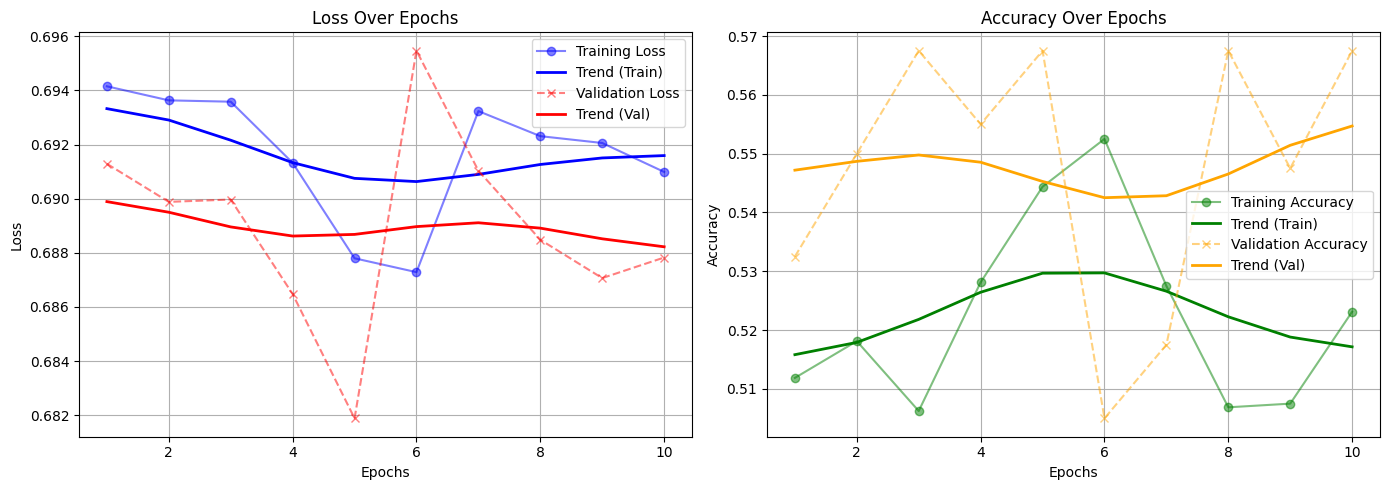

In [45]:
plot_loss_accuracy(history)

In [46]:
# BEGIN YOUR CODE HERE
# What is the loss and accuracy on the Testing dataset?
evaluation = model.evaluate(X_test, y_test) #accuracy: 0.5611 - loss: 0.6912
print(f"Test Loss: {evaluation[0]:.4f}") #Test Loss: 0.6925

print(f"Test Accuracy: {evaluation[1]:.4f}") #Test Accuracy: 0.5195
# https://www.tensorflow.org/api_docs/python/tf/keras/Model#evaluate
# When you print the output of the evaluate function, it will return both
# the loss and accuracy, maybe in a  format like [loss_value, accuracy_value]
# Display the confusion matrix, precision, recall and f1-score
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
report = classification_report(y_test, y_pred, target_names=['Negative', 'Positive'])
print("\nClassification Report:")
print(report)
#cm = tf.math.confusion_matrix(y_test, (model.predict(X_test) > 0.5).astype(int).flatten())

#print(cm)

# If you are using the model.predict function, you will have to do some postprocessing
# eg:
# y_pred_probs = model.predict(X_test)
# y_pred = (y_pred_probs > 0.5).astype(int).flatten()

### End your code here

# What is the accuracy you get?
# If you get an accuracy of aprox 50%, what does it mean? Did your model learn?
# Try to modify the architecture; how you train the model or how much data you
# use to train it in order to improve the results.


63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - accuracy: 0.3391 - loss: 0.6977
Test Loss: 0.6898
Test Accuracy: 0.5445
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 150ms/step

Confusion Matrix:
[[867 133]
 [778 222]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.53      0.87      0.66      1000
    Positive       0.63      0.22      0.33      1000

    accuracy                           0.54      2000
   macro avg       0.58      0.54      0.49      2000
weighted avg       0.58      0.54      0.49      2000



Test the model with a random text


In [ ]:
test_samples = []

# normally in python we have one line per instruction. Defining a long string
# will be difficult to read if it is only in one line. The way that we tell
# the interpreter that we have an instruction that spans several lines
# is by using the character \
review1 = "Petter Mattei's 'Love in the Time of Money' is a visually stunning"\
          "film to watch. Mr. Mattei offers us a vivid portrait about human" \
          " This is a movie that seems to be telling us what money, power and" \
          "success do to people"
### Begin your code here
# Write a couple of reviews and analyse how the model performs on your own data.
# Are the results what you expect?
# What did you change in the network architecture to get better results?
review2 = "Avatar: The Way of Water is a gorgeous film that doesn’t quite know what to do with its own world."\
"The CGI is undeniably impressive — some of the underwater sequences look almost real"\
"but the story moves in circles and rarely gives its characters anything meaningful to do."\
"Scenes that should feel emotional often feel stretched out, and the pacing makes the film feel longer than it needs to be."\
"It’s a visual triumph wrapped around a strangely empty core."
review3 = "Dune: Part Two is a powerful and confident continuation of Villeneuve’s vision."\
"The film builds tension with care and delivers moments that feel grand without losing their emotional weight."\
"The performances land, the world feels lived in, and the CGI blends seamlessly into the storytelling"\
"— especially in the large-scale desert sequences, which look stunning."\
"It’s the kind of sequel that expands the universe while staying focused,"\
"and it delivers on nearly every promise made by the first film."
### End your code here

test_samples.append(review1)
test_samples.append(review2)
test_samples.append(review3)

# test_samples_preprocess = np.array(list(map(lambda x: preprocess(x, len(test_samples)), test_samples)))
test_samples_preprocess = list(map(lambda x: preprocess(x, len(test_samples)), test_samples))
print(test_samples_preprocess)
print(trigrams[bigrams[test_samples_preprocess]])
test_data_bigrams = trigrams[bigrams[test_samples_preprocess]]
test_data_pad = pad_sequences(
sequences=vectorize_data(test_data_bigrams, vocab=trigram_model.wv.key_to_index),
maxlen=input_length,
padding='post')

predictions = model.predict(test_data_pad)
#print(predictions)

for (t, p) in zip( test_samples, predictions):
    prediction_string = "positive"
    if p<0.5:
        prediction_string = "negative"
    print("Predicted "+prediction_string+" "+str(p)+" for review:"+ t)
